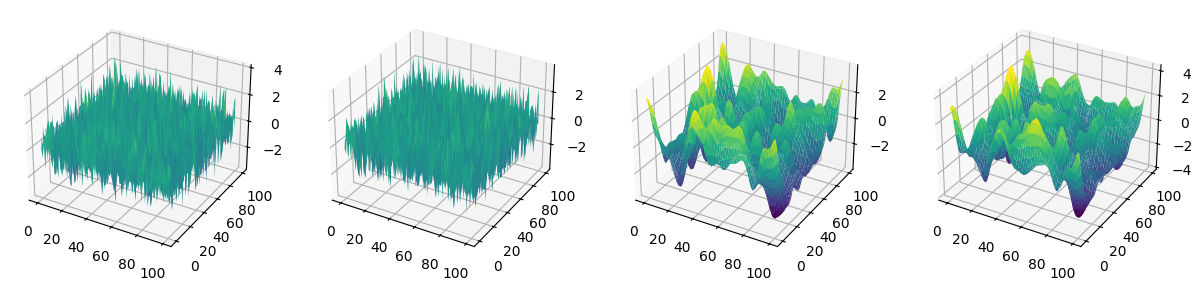

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage


def _scale_gaussian_variance(std):
    """
    Variance scaling for smoothing with 2D Gaussian
    https://matthew-brett.github.io/teaching/random_fields.html
    """
    limit = std * 5  # \approx 0
    xs = np.arange(-limit, limit + 1)
    ys = xs
    x, y = np.meshgrid(xs, ys)
    gaussian_2d = np.exp(-(x**2 + y**2) / (2 * std**2))
    gaussian_2d = gaussian_2d / gaussian_2d.sum()  # sum = 1
    gaussian_2d_fft = np.fft.fft2(gaussian_2d)  # frequency domain
    gaussian_2d_psd = gaussian_2d_fft * np.conj(gaussian_2d_fft)  # magnitude of frequency domain
    gaussian_2d_cov = np.real(np.fft.ifft2(gaussian_2d_psd))  # covariance matrix
    return gaussian_2d_cov[0, 0]  # variance at center of gaussian kernel


def smooth_img(img, std):
    """Smooth image by applyting a Gaussian filer.

    Parameters
    ----------
    img : ndarray of shape (n_pixels, n_pixels)
        _description_
    std : float
        The standard deviation of the smoothing kernel.

    Returns
    -------
    img_smoothed " ndarray of shape (n_pixels, n_pixels)
        The smoothed image, with the same mean and std of the input image.
    """
    std_scaling_factor = np.sqrt(1 / _scale_gaussian_variance(std))
    img_smoothed = ndimage.gaussian_filter(img, sigma=std, mode="wrap")
    img_smoothed = img_smoothed * std_scaling_factor  # scale to unit variance
    return img_smoothed


# initialize parameters
rng = np.random.default_rng(seed=0)
shape = (100, 100)
fwhm = 8  # n_points in x, y
std = fwhm / (2 * np.sqrt(2 * np.log(2)))  # convert fwhm to std for Gaussian dist.

# simulate img0 and img1 with correlation rho
rho = 0.8
imgs = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=shape)
imgs = imgs - imgs.mean(axis=(0, 1))  # mean center
img0_smoothed = smooth_img(imgs[:, :, 0], std)
img1_smoothed = smooth_img(imgs[:, :, 1], std)

# plot img0 and img1
fig, axs = plt.subplots(1, 4, figsize=(15, 4), subplot_kw=dict(projection="3d"))
plot_surface_kwargs = dict(vmin=-std, vmax=std, cmap="viridis", edgecolor="none")

x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))

axs[0].plot_surface(x, y, imgs[:, :, 0], **plot_surface_kwargs)
axs[1].plot_surface(x, y, imgs[:, :, 1], **plot_surface_kwargs)
axs[2].plot_surface(x, y, img0_smoothed, **plot_surface_kwargs)
axs[3].plot_surface(x, y, img1_smoothed, **plot_surface_kwargs)

In [2]:
# !!! 10sec runtime !!!
def estimate_rho_hat(img):
    """Estimate the sample correlation (`rho hat`) between two flattened images (vectors)."""
    img_to_vec = img.reshape(-1, img.shape[-1])
    return img_to_vec[:, 0].dot(img_to_vec[:, 1]) / img_to_vec.shape[0]


# initialize simulation results
n_simulations = 1000
rhos = [0.0, 0.3, 0.6, 0.9]  # cross-correlation parameters
simulations = {
    f"{rho}_{suffix}": np.zeros(n_simulations) for rho in rhos for suffix in ["img", "img-smoothed"]
}

for rho in rhos:
    for sim in range(n_simulations):
        # generate images
        imgs = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=shape)
        imgs = imgs - imgs.mean(axis=(0, 1))  # mean center
        img0_smoothed = smooth_img(imgs[:, :, 0], std)
        img1_smoothed = smooth_img(imgs[:, :, 1], std)
        imgs_smoothed = np.dstack([img0_smoothed, img1_smoothed])

        # estimate rho hats
        rho_hat = estimate_rho_hat(imgs)
        rho_hat_smoothed = estimate_rho_hat(imgs_smoothed)

        # save estimates for plotting
        simulations[f"{rho}_img"][sim] = rho_hat
        simulations[f"{rho}_img-smoothed"][sim] = rho_hat_smoothed

Text(0.5, 1.0, '$\\hat{\\rho}_\\text{smoothed}$')

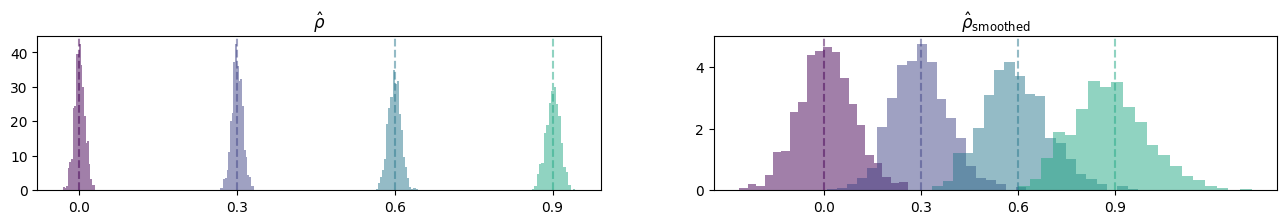

In [3]:
# plot simulations
colors = plt.cm.viridis(np.linspace(0, 1, len(rhos) + 2))
hist_kwargs = dict(bins=20, alpha=0.5, density=True)
vline_kwargs = dict(ls="--", alpha=0.5)

fig, axs = plt.subplots(1, 2, figsize=(16, 2))
for rho, color in zip(rhos, colors):
    axs[0].hist(simulations[f"{rho}_img"], color=color, **hist_kwargs)
    axs[0].axvline(rho, color=color, **vline_kwargs)
    axs[1].hist(simulations[f"{rho}_img-smoothed"], color=color, **hist_kwargs)
    axs[1].axvline(rho, color=color, **vline_kwargs)

axs[0].set_xticks(rhos)
axs[1].set_xticks(rhos)
axs[0].set_title(r"$\hat{\rho}$")
axs[1].set_title(r"$\hat{\rho}_\text{smoothed}$")